# Overinventory Optimization. A Capital Allocation Approach.

## 1. Executive Summary.

This project reframes inventory replenishment from a routine operational task into a **working-capital allocation decision**.

A linear optimization model determines when inventory investment is justified, balancing holding costs against service-level requirements at the SKU level.

At the store level, the optimized policy reduces weekly inventory-related costs from **4,487.74 MXN to 4,387.16 MXN**, generating **100.58 MXN in weekly savings per store**, while maintaining a **94.87% service level**.

Scaled across a **13,000-store retail network**, this decision discipline delivers approximately **67.99 million MXN in annual cost reduction**, equivalent to **~4.0 million USD**.

This result is not driven by aggressive cost-cutting, but by consistent, economically justified decisions applied at scale. Inventory is treated as deployable capital—allocated only where it delivers measurable service value.

This approach establishes a financially grounded, scalable framework for inventory management, directly linking operational decisions to working-capital efficiency.

## 2. Business Context.

Chronic **overinventory** emerged as a recurring operational challenge within **FEMSA’s convenience store network**, where retail operations teams were responsible for driving cross-functional initiatives to improve efficiency, reduce costs, and support sales performance.

Inventory inefficiencies can emerge from decentralized replenishment dynamics and inconsistent execution across supply channels.

In several product categories and store locations, excess inventory accumulated despite replenishment rules designed to protect product availability. Supply Chain teams raised concerns that elevated stock levels were increasing:

* **Shrinkage and spoilage risk.**
* **Handling and storage costs.**
* **Operational inefficiencies in replenishment processes.**

The situation required a coordinated analysis to determine whether existing replenishment logic was **systematically generating excess stock under certain conditions**.

Retail replenishment systems typically rely on **coverage-based formulas** designed to prevent stockouts. However, operational observations suggested that these heuristics could sometimes lead stores to **hold more inventory than economically justified**, particularly when product velocity differences and shelf-space constraints were not fully reflected in reorder logic.

### 2.1 Financial Impact Framing.

Beyond operational inefficiencies, chronic overinventory represents a **capital allocation problem**.

Excess stock ties up **working capital** that could otherwise be deployed toward:

* Higher-velocity products.
* Promotional initiatives.
* Store expansion or operational investments.

The scale of this issue becomes particularly significant in large retail systems such as **OXXO**, which operated more than **13,000 stores in Mexico in 2014** (and more than **23,000 today**).

Even **marginal excess inventory per SKU** can translate into substantial capital lock-up and avoidable carrying costs when multiplied across **thousands of stores and product categories**.

Addressing this challenge required evaluating whether **analytical decision frameworks** could support more financially disciplined reorder policies while preserving the service levels expected in high-frequency retail operations.







## 3. Analytical Objective.

Operational observations across multiple stores suggested that inventory levels were not always being driven purely by demand dynamics. In several cases, store teams increased purchase orders manually in an effort to protect product availability, unintentionally contributing to persistent overstocking.

While this behavior was operationally understandable, it introduced additional inventory carrying costs and created inconsistencies in replenishment decisions across the network.

The analytical objective of this project is therefore to determine **economically optimal reorder quantities for each store–SKU combination**, balancing the need to protect product availability with the financial cost of holding excess inventory.

Specifically, the analysis seeks to evaluate whether a structured optimization framework can support more disciplined replenishment decisions by explicitly incorporating:

* Inventory holding costs.
* Service-level protection.
* Stockout risk.
* Shelf capacity constraints.

By formalizing these trade-offs, the analysis aims to support a more consistent and financially efficient inventory policy across the retail network.


## 4. Approach.

To address the overinventory challenge, this project formulates the replenishment decision as a **prescriptive optimization problem**. The goal is to determine economically efficient reorder quantities for each **store–SKU combination**, balancing service protection against the financial cost of excess inventory.

Rather than assuming that all operational rules can always be satisfied simultaneously, the modeling process is designed to test feasibility under real retail constraints. This is important because shelf capacity, current stock levels, and demand requirements often create structural trade-offs that cannot be resolved through simple rule-based ordering.

The analytical workflow follows six stages:

a) Define the optimization problem, decision variables, and cost-minimization objective.

b) Encode operational constraints reflecting real retail conditions, including shelf capacity, demand coverage, and current inventory levels.

c) Validate the formulation at the single-store level to observe SKU-level replenishment decisions and confirm the feasibility of the cost–service trade-off.

d) Diagnose infeasibility when strict operational constraints cannot be simultaneously satisfied.

f) Refine the model using slack variables and penalty-based logic to represent realistic service flexibility.

g) Evaluate optimized decisions against a rule-based baseline and assess the financial implications when the decision logic is applied across a simulated store network.

This structure reflects a realistic prescriptive analytics process: start with a strict business rule, test its feasibility, refine the formulation when necessary, and then evaluate whether optimization improves decision quality relative to standard operational practice.

### 4.1 Optimization Problem Definition.

The overinventory decision is first modeled as a **cost-minimization optimization problem**. At the SKU level, the model determines how much to reorder while minimizing the total financial burden associated with inventory decisions.

The objective function incorporates three cost components:

- **Holding Cost.**  
  Cost of carrying inventory beyond immediate sales needs, reflecting working capital tied up in stock.

- **Spoilage or Shrinkage Risk.**  
  Risk-weighted cost associated with deterioration, low rotation, or product loss.

- **Service-Level Penalty.**  
  A penalty applied when the desired stock coverage target cannot be fully achieved.

The model therefore evaluates the trade-off between **protecting product availability** and **avoiding unnecessary inventory accumulation**.

Decision variables include:

- Reorder quantity per SKU.
- A service-related adjustment term introduced later if strict feasibility cannot be maintained.

In [1]:
# Install dependency
!pip install pulp

import os
import pandas as pd

file_path = "overinventory_synthetic_data.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    print("Upload dataset:")
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])

Upload dataset:


Saving overinventory_synthetic_database.csv to overinventory_synthetic_database.csv


In [2]:
file_path = "overinventory_synthetic_data.csv"

# Normalize column names
df.columns = df.columns.str.replace(" ", "_")

### 4.2 Operational Constraints and Business Logic.

The initial model encodes the main physical and operational restrictions that shape replenishment decisions in a retail environment.

a) The first constraint is **maximum shelf capacity per SKU**, which prevents reorder recommendations from exceeding the display or storage limit assigned to each product.

b) The second constraint is **total store shelf space**, reflecting the fact that products compete for limited merchandising area and that store-level space must remain physically feasible.

c) The third constraint is **minimum demand coverage**. In the initial strict formulation, the model attempts to maintain inventory equivalent to **1.5× average weekly demand**, net of current stock already available in the store.

Together, these rules reflect a common retail tension: the business wants high availability, and physical space and cost discipline impose hard limits on how much inventory can realistically be held.

### 4.3 Initial Single-Store Validation and Feasibility Test.

Before extending the model across the full simulated network, the optimization logic is first tested on a **single store**. This controlled setting makes it easier to inspect the interaction between decision variables, cost logic, and operational constraints.

The purpose of this first run is not only to obtain a solution, but also to verify whether the strict business rules are jointly feasible under actual store conditions.

In this project, the initial formulation returns an **infeasible solution**. This result is analytically important: it shows that the combination of shelf limits and strict demand coverage requirements cannot always be satisfied simultaneously.

Rather than treating infeasibility as a coding failure, it is interpreted as a **diagnostic finding**. In operational terms, it reveals that real store capacity may be insufficient to meet a rigid service target across all SKUs at the same time.

In [6]:
['Store_ID', 'SKU_ID', 'Current_Stock', 'Avg_Weekly_Demand',
 'Max_Shelf_Capacity', 'Total_Shelf_Space', 'Holding_Cost_per_Unit']


['Store_ID',
 'SKU_ID',
 'Current_Stock',
 'Avg_Weekly_Demand',
 'Max_Shelf_Capacity',
 'Total_Shelf_Space',
 'Holding_Cost_per_Unit']

In [7]:
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpStatus
# Select one store
store_id = "STR001"
store_df = df[df["Store_ID"] == store_id].copy()

# Build LP model
prob = LpProblem(f"Inventory_Optimization_{store_id}", LpMinimize)

# Decision variables: reorder quantity per SKU
reorder_vars = {
    row["SKU_ID"]: LpVariable(f"Reorder_{row['SKU_ID']}", lowBound=0, cat="Integer")
    for _, row in store_df.iterrows()
}

# Objective function: Minimize holding + spoilage penalty
prob += lpSum([
    reorder_vars[row['SKU_ID']] * (
        row['Holding_Cost_per_Unit'] + (row['Spoilage_Risk'] * 0.1)
    )
    for _, row in store_df.iterrows()
]), "Total_Cost"

# Constraint 1: Total shelf space used across SKUs ≤ store capacity
total_shelf_space = store_df['Total_Shelf_Space'].iloc[0]
prob += lpSum([
    reorder_vars[row['SKU_ID']] for _, row in store_df.iterrows()
]) <= total_shelf_space, "Shelf_Space_Constraint"

# Constraint 2 & 3: Per-SKU shelf max and minimum demand coverage
for _, row in store_df.iterrows():
    sku = row['SKU_ID']
    current_stock = row['Current_Stock']
    avg_demand = row['Avg_Weekly_Demand']
    min_required = max(0, avg_demand * 1.5 - current_stock)

    # Do not exceed shelf capacity
    prob += reorder_vars[sku] <= row['Max_Shelf_Capacity'], f"Max_Shelf_{sku}"

    # Cover at least 1.5× demand (minus current stock)
    prob += reorder_vars[sku] >= min_required, f"Min_Stock_Target_{sku}"

# Solve model
prob.solve()

# Collect results
results = []
for _, row in store_df.iterrows():
    sku = row['SKU_ID']
    reorder_qty = reorder_vars[sku].varValue
    results.append({
        'Store_ID': store_id,
        'SKU_ID': sku,
        'Recommended_Reorder_Qty': int(reorder_qty),
        'Current_Stock': row['Current_Stock'],
        'Avg_Weekly_Demand': row['Avg_Weekly_Demand'],
        'Max_Shelf_Capacity': row['Max_Shelf_Capacity'],
        'Holding_Cost_per_Unit': row['Holding_Cost_per_Unit'],
        'Spoilage_Risk': row['Spoilage_Risk']
    })

# Save and show
result_df = pd.DataFrame(results)
result_df.to_csv(f"Reorder_Optimization_{store_id}.csv", index=False)
print(f"Optimization Status: {LpStatus[prob.status]}")
print(result_df.head())



Optimization Status: Infeasible
  Store_ID   SKU_ID  Recommended_Reorder_Qty  Current_Stock  \
0   STR001  SKU0001                        0             33   
1   STR001  SKU0002                        0              8   
2   STR001  SKU0003                        0             35   
3   STR001  SKU0004                        0             41   
4   STR001  SKU0005                        0             17   

   Avg_Weekly_Demand  Max_Shelf_Capacity  Holding_Cost_per_Unit  Spoilage_Risk  
0                 61                  59                   2.87           0.54  
1                 24                  28                   1.21           0.24  
2                 81                  65                   2.54           0.54  
3                 70                  57                   1.19           0.52  
4                 30                  29                   0.68           0.82  


### 4.4 Model Refinement: Introducing Slack Variables.

Because the strict formulation proved infeasible, the model is refined by introducing **slack variables** that represent controlled shortfalls in demand coverage.

This converts the rigid service requirement into a **soft constraint**. Instead of forcing every SKU to fully satisfy the target coverage level regardless of physical limitations, the model allows partial shortfalls when necessary, while assigning a financial penalty to those gaps.

Conceptually, the service rule changes from:

**Reorder Quantity + Current Stock ≥ Target Coverage.**

to:

**Reorder Quantity + Current Stock + Unmet Demand Buffer ≥ Target Coverage.**

This refinement preserves the managerial priority of service protection, but recognizes that operational constraints may require compromise. The penalty assigned to unmet coverage is intentionally set higher than routine inventory holding cost, so the model continues to discourage service erosion unless it is justified by binding physical constraints.

In [8]:
# Select one store for the optimization example
store_id = "STR001"
store_df = df[df["Store_ID"] == store_id].copy()

# Build LP model
prob = LpProblem(f"Inventory_Optimization_{store_id}", LpMinimize)

# Decision variables: reorder quantity per SKU
reorder_vars = {
    row["SKU_ID"]: LpVariable(f"Reorder_{row['SKU_ID']}", lowBound=0, cat="Integer")
    for _, row in store_df.iterrows()
}

# Slack variables: unmet demand buffer
unmet_demand_vars = {
    row["SKU_ID"]: LpVariable(f"Unmet_{row['SKU_ID']}", lowBound=0, cat="Continuous")
    for _, row in store_df.iterrows()
}

# Objective function: minimize inventory cost and penalized unmet demand
prob += lpSum(
    reorder_vars[row["SKU_ID"]] * (
        row["Holding_Cost_per_Unit"] + row["Spoilage_Risk"] * 0.1
    )
    + unmet_demand_vars[row["SKU_ID"]] * 2.0
    for _, row in store_df.iterrows()
), "Total_Cost_With_Service_Buffer"

# Constraint 1: Reorder quantity cannot exceed SKU shelf capacity
for _, row in store_df.iterrows():
    sku = row["SKU_ID"]
    prob += reorder_vars[sku] <= row["Max_Shelf_Capacity"], f"MaxShelf_{sku}"

# Constraint 2: Total reorder quantity must fit within available store shelf space
total_shelf_space = store_df["Total_Shelf_Space"].iloc[0]
prob += lpSum(reorder_vars[sku] for sku in reorder_vars) <= total_shelf_space, "Shelf_Space"

# Constraint 3: Combined current stock, reorder, and buffer must cover target demand
for _, row in store_df.iterrows():
    sku = row["SKU_ID"]
    target_stock = row["Avg_Weekly_Demand"] * 1.5
    current_stock = row["Current_Stock"]

    prob += (
        reorder_vars[sku] + current_stock + unmet_demand_vars[sku] >= target_stock
    ), f"DemandBuffer_{sku}"

# Solve model
prob.solve()

# Collect results
results = []

for _, row in store_df.iterrows():
    sku = row["SKU_ID"]
    results.append({
        "Store_ID": store_id,
        "SKU_ID": sku,
        "Recommended_Reorder_Qty": int(reorder_vars[sku].varValue),
        "Unmet_Demand_Buffer": round(unmet_demand_vars[sku].varValue, 2),
        "Current_Stock": row["Current_Stock"],
        "Avg_Weekly_Demand": row["Avg_Weekly_Demand"],
        "Max_Shelf_Capacity": row["Max_Shelf_Capacity"],
        "Holding_Cost_per_Unit": row["Holding_Cost_per_Unit"],
        "Spoilage_Risk": row["Spoilage_Risk"]
    })

result_df = pd.DataFrame(results)

# Save optimization output
result_df.to_csv(f"overinventory_optimization_results_{store_id}.csv", index=False)

# Summary
print(f"Optimization Status: {LpStatus[prob.status]}")
display(result_df.head())




Optimization Status: Optimal


,Store_ID,SKU_ID,Recommended_Reorder_Qty,Unmet_Demand_Buffer,Current_Stock,Avg_Weekly_Demand,Max_Shelf_Capacity,Holding_Cost_per_Unit,Spoilage_Risk
0,STR001,SKU0001,0,58.5,33,61,59,2.87,0.54
1,STR001,SKU0002,0,28.0,8,24,28,1.21,0.24
2,STR001,SKU0003,0,86.5,35,81,65,2.54,0.54
3,STR001,SKU0004,0,64.0,41,70,57,1.19,0.52
4,STR001,SKU0005,28,0.0,17,30,29,0.68,0.82


### 4.5 Interpreting the Refined Optimization Logic.

With slack variables introduced, the optimization becomes feasible and produces a solution that better reflects real retail conditions.

The resulting policy does not force inventory expansion where shelf capacity is already binding. Instead, it selectively recommends reorder quantities only where additional stock can be supported economically and physically. Where full demand coverage cannot be achieved, the model records a measurable shortfall rather than hiding the conflict.

This is an important feature of the approach: the model does not pretend that all service targets are universally attainable. It explicitly quantifies where operational limitations prevent full compliance and incorporates that trade-off into the cost structure.

### 4.6 Policy Comparison: Rule-Based Replenishment vs. Optimization.

To evaluate the value of the optimization model, its recommendations are compared against a simplified **rule-based replenishment policy** designed to approximate conventional operational practice.

The baseline policy replenishes inventory according to expected demand while respecting shelf capacity limits, but it does not optimize explicitly across competing cost components. By contrast, the optimization model selects reorder decisions by minimizing total operational cost while balancing service protection, overstock risk, and disposal-related penalties.

This comparison is essential because it moves the project beyond mathematical feasibility. It tests whether optimization actually improves inventory decisions relative to a more traditional replenishment logic.

In [9]:
# ==========================================================
# Rule-Based Baseline vs Optimized LP
# ==========================================================

from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpStatus, value

store_id = "STR001"

service_target = 0.90
stockout_multiplier = 8
spoilage_multiplier = 10
disposal_multiplier = 2

# Use the dataframe already loaded at the beginning of the notebook
store_df = df[df["Store_ID"] == store_id].copy()

num_cols = [
    "Current_Stock",
    "Avg_Weekly_Demand",
    "Max_Shelf_Capacity",
    "Holding_Cost_per_Unit",
    "Spoilage_Risk"
]

for c in num_cols:
    store_df[c] = pd.to_numeric(store_df[c], errors="coerce")

store_df["Stockout_Penalty"] = store_df["Holding_Cost_per_Unit"] * stockout_multiplier
store_df["Spoilage_Cost"] = (
    store_df["Holding_Cost_per_Unit"] * spoilage_multiplier * store_df["Spoilage_Risk"]
)
store_df["Disposal_Cost"] = store_df["Holding_Cost_per_Unit"] * disposal_multiplier

total_demand = store_df["Avg_Weekly_Demand"].sum()

print(f"Store: {store_id}")
print(f"Service Target: {service_target * 100:.0f}%")
print("Baseline: Rule-Based Replenishment")

# Baseline
baseline_holding = baseline_spoilage = baseline_stockout = baseline_disposal = 0
base_fulfilled = 0

for _, r in store_df.iterrows():
    current = r["Current_Stock"]
    demand = r["Avg_Weekly_Demand"]
    cap = r["Max_Shelf_Capacity"]

    emergency_dispose = max(current - cap, 0)
    current_adj = current - emergency_dispose

    order_qty = max(min(demand - current_adj, cap - current_adj), 0)

    on_hand = current_adj + order_qty
    fulfilled_qty = min(on_hand, demand)
    stockout_qty = max(demand - fulfilled_qty, 0)
    overstock_qty = max(on_hand - fulfilled_qty, 0)

    baseline_disposal += emergency_dispose * r["Disposal_Cost"]
    baseline_holding += overstock_qty * r["Holding_Cost_per_Unit"]
    baseline_spoilage += overstock_qty * r["Spoilage_Cost"]
    baseline_stockout += stockout_qty * r["Stockout_Penalty"]

    base_fulfilled += fulfilled_qty

baseline_total = (
    baseline_holding
    + baseline_spoilage
    + baseline_stockout
    + baseline_disposal
)

baseline_service = base_fulfilled / total_demand

# Optimized LP
prob = LpProblem("Inventory_Optimization", LpMinimize)

order = {}
dispose = {}
fulfilled = {}
overstock = {}
stockout = {}

for _, r in store_df.iterrows():
    sku = r["SKU_ID"]
    current = r["Current_Stock"]

    order[sku] = LpVariable(f"Order_{sku}", lowBound=0)
    dispose[sku] = LpVariable(f"Dispose_{sku}", lowBound=0, upBound=current)
    fulfilled[sku] = LpVariable(f"Fulfilled_{sku}", lowBound=0)
    overstock[sku] = LpVariable(f"Overstock_{sku}", lowBound=0)
    stockout[sku] = LpVariable(f"Stockout_{sku}", lowBound=0)

prob += lpSum(
    overstock[r["SKU_ID"]] * r["Holding_Cost_per_Unit"]
    + overstock[r["SKU_ID"]] * r["Spoilage_Cost"]
    + stockout[r["SKU_ID"]] * r["Stockout_Penalty"]
    + dispose[r["SKU_ID"]] * r["Disposal_Cost"]
    for _, r in store_df.iterrows()
)

for _, r in store_df.iterrows():
    sku = r["SKU_ID"]
    current = r["Current_Stock"]
    demand = r["Avg_Weekly_Demand"]
    cap = r["Max_Shelf_Capacity"]

    prob += fulfilled[sku] <= demand
    prob += fulfilled[sku] <= current - dispose[sku] + order[sku]
    prob += stockout[sku] >= demand - fulfilled[sku]
    prob += overstock[sku] >= current - dispose[sku] + order[sku] - fulfilled[sku]
    prob += current - dispose[sku] + order[sku] <= cap

prob += (
    lpSum(fulfilled[sku] for sku in store_df["SKU_ID"])
    >= service_target * total_demand
)

prob.solve()

status = LpStatus[prob.status]
print(f"Solver Status: {status}")

if status == "Optimal":
    opt_holding = opt_spoilage = opt_stockout = opt_disposal = 0
    opt_fulfilled = 0

    for _, r in store_df.iterrows():
        sku = r["SKU_ID"]

        over = value(overstock[sku])
        stko = value(stockout[sku])
        disp = value(dispose[sku])
        ful = value(fulfilled[sku])

        opt_holding += over * r["Holding_Cost_per_Unit"]
        opt_spoilage += over * r["Spoilage_Cost"]
        opt_stockout += stko * r["Stockout_Penalty"]
        opt_disposal += disp * r["Disposal_Cost"]
        opt_fulfilled += ful

    opt_total = opt_holding + opt_spoilage + opt_stockout + opt_disposal
    opt_service = opt_fulfilled / total_demand

    savings = baseline_total - opt_total
    savings_pct = savings / baseline_total * 100

    print("\nBASELINE")
    print(f"Total Cost: {baseline_total:,.2f}")
    print(f"Service: {baseline_service * 100:.2f}%")

    print("\nOPTIMIZED")
    print(f"Total Cost: {opt_total:,.2f}")
    print(f"Service: {opt_service * 100:.2f}%")

    print("\nIMPACT")
    print(f"Savings: {savings:,.2f}")
    print(f"Savings %: {savings_pct:.2f}%")

Store: STR001
Service Target: 90%
Baseline: Rule-Based Replenishment
Solver Status: Optimal

BASELINE
Total Cost: 4,487.74
Service: 94.87%

OPTIMIZED
Total Cost: 4,387.16
Service: 94.87%

IMPACT
Savings: 100.58
Savings %: 2.24%


### 4.7 Scaling the Optimization Across the Store Network.

After validating the model logic at the single-store level, the optimization framework is extended across the full simulated retail network.

Each store is treated as an independent optimization instance operating under the same replenishment logic, cost structure, and service rules.

This allows the project to move from a local proof of concept to a scalable decision-support framework.

Running the model across all stores makes it possible to capture broader patterns in inventory pressure, constraint-driven shortfalls, and potential efficiency gains across the network.

This step is important because overinventory is not only a SKU-level issue, but a system-wide capital allocation problem.

In [10]:
# Get all unique store IDs
store_ids = df["Store_ID"].unique()

# Placeholder for all optimization results
all_results = []

# Loop through each store
for store_id in store_ids:
    store_df = df[df["Store_ID"] == store_id].copy()

    # Build LP model
    prob = LpProblem(f"Inventory_Optimization_{store_id}", LpMinimize)

    # Decision variables: reorder quantity per SKU
    reorder_vars = {
        row["SKU_ID"]: LpVariable(f"Reorder_{row['SKU_ID']}", lowBound=0, cat="Integer")
        for _, row in store_df.iterrows()
    }

    # Slack variables: unmet demand buffer
    unmet_demand_vars = {
        row["SKU_ID"]: LpVariable(f"Unmet_{row['SKU_ID']}", lowBound=0, cat="Continuous")
        for _, row in store_df.iterrows()
    }

    # Objective function: minimize inventory cost and penalized unmet demand
    prob += lpSum(
        reorder_vars[row["SKU_ID"]] * (
            row["Holding_Cost_per_Unit"] + row["Spoilage_Risk"] * 0.1
        )
        + unmet_demand_vars[row["SKU_ID"]] * 2.0
        for _, row in store_df.iterrows()
    ), "Total_Cost_With_Service_Buffer"

    # Constraint 1: Reorder quantity cannot exceed SKU shelf capacity
    for _, row in store_df.iterrows():
        sku = row["SKU_ID"]
        prob += reorder_vars[sku] <= row["Max_Shelf_Capacity"], f"MaxShelf_{store_id}_{sku}"

    # Constraint 2: Total reorder quantity must fit within available store shelf space
    total_shelf_space = store_df["Total_Shelf_Space"].iloc[0]
    prob += (
        lpSum(reorder_vars[sku] for sku in reorder_vars) <= total_shelf_space
    ), f"ShelfSpace_{store_id}"

    # Constraint 3: Combined current stock, reorder, and buffer must cover target demand
    for _, row in store_df.iterrows():
        sku = row["SKU_ID"]
        target_stock = row["Avg_Weekly_Demand"] * 1.5
        current_stock = row["Current_Stock"]

        prob += (
            reorder_vars[sku] + current_stock + unmet_demand_vars[sku] >= target_stock
        ), f"DemandBuffer_{store_id}_{sku}"

    # Solve model
    prob.solve()

    # Capture solver status
    status = LpStatus[prob.status]

    # Collect results
    for _, row in store_df.iterrows():
        sku = row["SKU_ID"]

        all_results.append({
            "Store_ID": store_id,
            "Solver_Status": status,
            "SKU_ID": sku,
            "Recommended_Reorder_Qty": int(reorder_vars[sku].varValue) if status == "Optimal" else None,
            "Unmet_Demand_Buffer": round(unmet_demand_vars[sku].varValue, 2) if status == "Optimal" else None,
            "Current_Stock": row["Current_Stock"],
            "Avg_Weekly_Demand": row["Avg_Weekly_Demand"],
            "Max_Shelf_Capacity": row["Max_Shelf_Capacity"],
            "Holding_Cost_per_Unit": row["Holding_Cost_per_Unit"],
            "Spoilage_Risk": row["Spoilage_Risk"]
        })

# Final dataset with all stores and SKUs
result_df = pd.DataFrame(all_results)

# Save optimization output
result_df.to_csv("overinventory_optimization_results_all_stores.csv", index=False)

print("Optimization complete for all stores.")
print(result_df["Solver_Status"].value_counts())

Optimization complete for all stores.
Solver_Status
Optimal    15000
Name: count, dtype: int64


### 4.8 Financial Translation of Optimization Impact.

To translate the analytical output into business language, the per-store improvement is converted into an annualized financial estimate and then extrapolated across a larger retail network.

This step does not change the optimization model itself. Instead, it frames the results in executive terms by showing how a modest weekly efficiency gain at the store level can accumulate into a more meaningful annual impact when scaled across thousands of locations.

Including this translation strengthens the practical relevance of the project by connecting model performance to broader discussions of cost control, working capital discipline, and retail operating efficiency.

In [11]:
# ==========================================================
# Executive Financial Translation — MXN & USD
# Per Store and 13,000 Stores
# ==========================================================

# --- Adjustable Inputs ---
stores_network = 13000
weeks_per_year = 52
fx_rate = 17.0   # MXN per USD (adjust to current rate if needed)

# --- Safety Check ---
if 'baseline_total' not in globals() or 'opt_total' not in globals():
    raise ValueError("baseline_total and opt_total must exist. Run the optimization cell first.")

# --- Weekly Savings Per Store ---
weekly_savings_mxn = baseline_total - opt_total

# --- Annual Savings Per Store ---
annual_savings_per_store_mxn = weekly_savings_mxn * weeks_per_year

# --- Network Annual Savings ---
annual_savings_network_mxn = annual_savings_per_store_mxn * stores_network

# --- USD Conversion ---
annual_savings_per_store_usd = annual_savings_per_store_mxn / fx_rate
annual_savings_network_usd = annual_savings_network_mxn / fx_rate

# --- Output ---
print("==================================================")
print("EXECUTIVE FINANCIAL IMPACT")
print("==================================================\n")

print("Per Store:")
print(f"Weekly Savings:        {weekly_savings_mxn:,.2f} MXN")
print(f"Annual Savings:        {annual_savings_per_store_mxn:,.2f} MXN")
print(f"Annual Savings:        ${annual_savings_per_store_usd:,.2f} USD\n")

print(f"Network Extrapolation ({stores_network:,} Stores):")
print(f"Annual Savings:        {annual_savings_network_mxn:,.2f} MXN")
print(f"Annual Savings:        ${annual_savings_network_usd:,.2f} USD")

print("\n==================================================")

EXECUTIVE FINANCIAL IMPACT

Per Store:
Weekly Savings:        100.58 MXN
Annual Savings:        5,230.16 MXN
Annual Savings:        $307.66 USD

Network Extrapolation (13,000 Stores):
Annual Savings:        67,992,080.00 MXN
Annual Savings:        $3,999,534.12 USD



### 4.9 Modeling Assumptions.

The optimization framework is based on a simplified, deterministic representation of the inventory decision environment:

a) Demand behavior is assumed stable over the planning horizon.  
b) Cost parameters (holding cost, service impact) are treated as deterministic.  
c) No stochastic variability or demand uncertainty is explicitly modeled.  
d) The formulation follows a single-period optimization logic at the SKU level.  

These assumptions allow for a clear interpretation of the cost–service trade-off, while keeping the model aligned with operational decision-making logic.

### 4.10 Approach Summary.

Overall, the modeling process moved from a strict initial formulation to a refined and scalable optimization framework better aligned with real retail constraints. The progression from infeasibility diagnosis to soft-constraint refinement, policy benchmarking, and financial translation strengthens the analytical credibility of the project and prepares the ground for a clearer evaluation of results.

The next section presents the main outputs of the model, including the cost comparison between baseline and optimized policies, the observed savings, and the broader financial significance of the recommended inventory decisions.

## 5. Key Results.

### 5.1 Single-Store Cost Comparison.

After refining the optimization model and benchmarking it against the rule-based replenishment policy, the first key result is the direct comparison of total cost at the **single-store level**.

This comparison is important because it isolates the effect of the optimization logic under the same store conditions, product mix, and service target. It allows the analysis to determine whether the optimized policy improves financial performance relative to a conventional replenishment approach.

| Policy | Total Cost (MXN) | Service Level | Savings (MXN) | Savings (%) |
|---|---:|---:|---:|---:|
| Rule-Based Baseline | 4,487.74 | 94.87% | — | — |
| Optimized LP | 4,387.16 | 94.87% | 100.58 | 2.24% |

### 5.2 Baseline vs Optimized Financial Outcome.

For the selected store, the optimization model reduced total inventory-related cost from **MXN 4,487.74** under the rule-based policy to **MXN 4,387.16** under the optimized policy.

This represents an absolute weekly saving of **MXN 100.58**, equivalent to a **2.24% reduction** in total cost, while maintaining the same observed service level of **94.87%**.

These results indicate that the model improved inventory efficiency without degrading service performance, showing that disciplined replenishment decisions can produce measurable financial gains while preserving service performance.

### 5.3 Interpreting the Magnitude of Savings.

The magnitude of the savings is intentionally modest rather than exaggerated. This strengthens the credibility of the result.

In retail operations, replenishment policies are often already designed to avoid obvious inefficiencies. For that reason, a realistic optimization model may not generate dramatic cost reductions at the individual store level. Its value lies in identifying disciplined, repeatable improvements that preserve service while reducing avoidable cost exposure.

In this case, the optimization framework demonstrates that a more structured decision model can outperform a conventional replenishment rule without relying on unrealistic assumptions or inflated savings claims.

### 5.4 Network-Level Optimization Output.

After validating the model at the single-store level, the same optimization logic was extended across the full simulated store network. The resulting output confirms that the model can be executed systematically across all store instances using the same decision structure.

This matters because overinventory is not only a local store issue. It is also a broader capital allocation problem across the retail network. The ability to run the model at scale strengthens its relevance as a deployable decision-support framework.

| Metric | Value |
|---|---:|
| Optimization Scope | Full simulated store network |
| Simulated Stores Processed | 150 |
| Total Store–SKU Records Processed | 15,000 |
| Solver Status | Optimal |
| Network Execution Status | Optimization complete for all simulated stores |
| Output File Generated | `Overinventory_WithSlack_ALL_Stores.csv` |

In [12]:
final_df = result_df.copy()


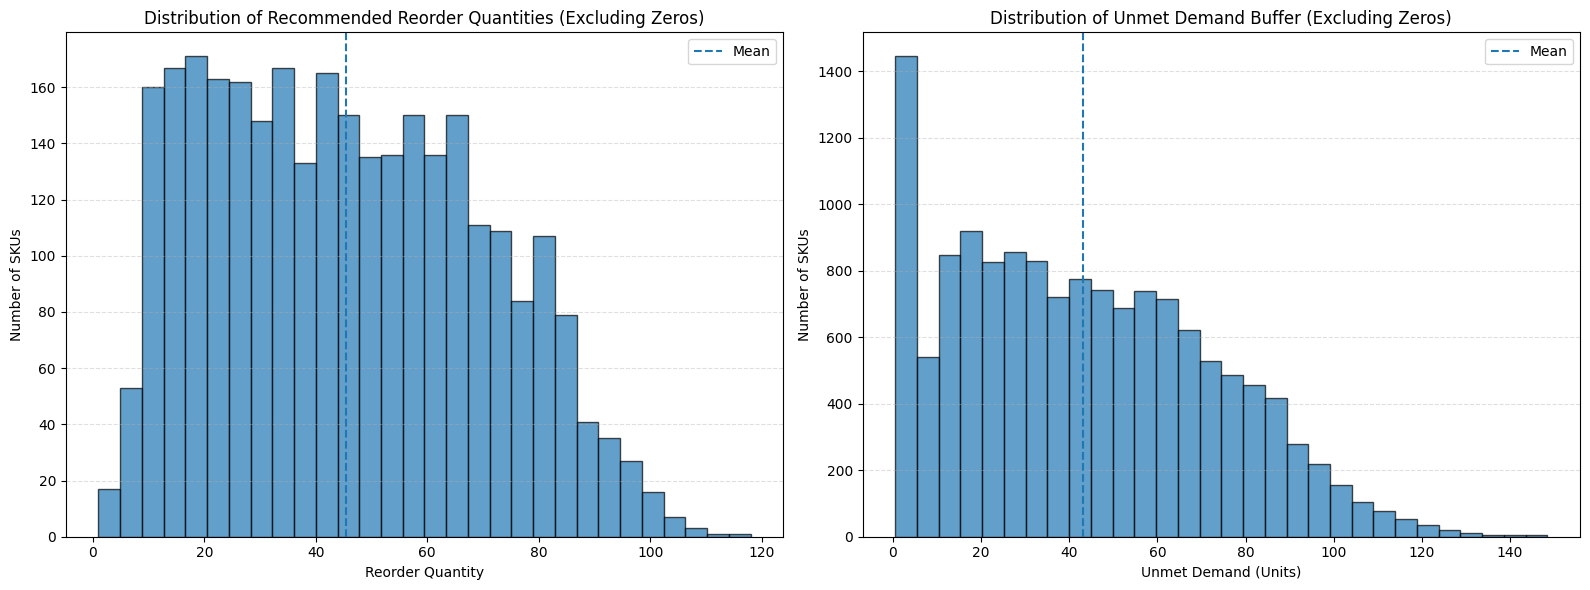

In [13]:
import matplotlib.pyplot as plt

# Filter out zero values to focus on active optimization decisions
nonzero_reorders = final_df[final_df["Recommended_Reorder_Qty"] > 0]["Recommended_Reorder_Qty"]
nonzero_unmet_demand = final_df[final_df["Unmet_Demand_Buffer"] > 0]["Unmet_Demand_Buffer"]

# Set up the figure
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Histogram 1: Recommended Reorder Quantity
axs[0].hist(nonzero_reorders, bins=30, edgecolor="black", alpha=0.7)
axs[0].axvline(nonzero_reorders.mean(), linestyle="--", label="Mean")
axs[0].set_title("Distribution of Recommended Reorder Quantities (Excluding Zeros)", fontsize=12)
axs[0].set_xlabel("Reorder Quantity")
axs[0].set_ylabel("Number of SKUs")

# Histogram 2: Unmet Demand Buffer
axs[1].hist(nonzero_unmet_demand, bins=30, edgecolor="black", alpha=0.7)
axs[1].axvline(nonzero_unmet_demand.mean(), linestyle="--", label="Mean")
axs[1].set_title("Distribution of Unmet Demand Buffer (Excluding Zeros)", fontsize=12)
axs[1].set_xlabel("Unmet Demand (Units)")
axs[1].set_ylabel("Number of SKUs")

# Improve readability
for ax in axs:
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.show()







### 5.5 Distribution of Optimized Decisions Across the Network.

These histograms depict how the optimization behaved across the **150-store simulated network**, focusing only on **active decisions** (non-zero reorder quantities and non-zero unmet demand buffers).

#### Reading the Pattern.

- **Reorder quantities cluster in moderate ranges.**  
  Most positive reorder decisions concentrate in the middle of the distribution, which suggests **selective capital deployment** rather than aggressive restocking.

- **Large reorder events are limited.**  
  The right tail is relatively thin, indicating that the model avoided widespread high-volume replenishment and reserved larger orders for a narrower set of higher-pressure SKU–store cases.

- **Unmet demand buffers are usually small.**  
  Most shortfalls remain in lower ranges, which suggests that the model preserved service as much as possible and only accepted limited gaps where the extra stock was not financially justified.

- **Extreme shortfalls are uncommon.**  
  The long right tail is present, but sparse. This indicates that structural pressure existed in some cases, yet broad service deterioration was not the dominant outcome.

Taken together, the visual pattern supports the financial results already observed in the project:

- **2.24% weekly cost reduction per store.**
- **94.87% service maintained.**
- **100.58 MXN weekly savings per store.**

In practical terms, the model did not generate savings by indiscriminate stock cuts. It generated them through **disciplined SKU-level decisions**, preserving working capital where possible and deploying it only where the service case was stronger.

### 5.6 Financial Translation at Scale.

Although the weekly saving observed at the single-store level is moderate, its strategic significance becomes clearer when translated into annual and network terms.

To make the result easier to interpret in business language, the store-level efficiency gain is annualized first at the **per-store level** and then extrapolated across a larger retail footprint. The two tables below summarize that translation.

The first table shows the estimated financial effect for one store over time. The second table presents the corresponding annual extrapolation across a network of **13,000 stores**.

In [14]:
# ==========================================================
# Financial Translation at Scale
# From model output to executive-level impact
# ==========================================================

# --- Adjustable inputs ---
simulated_stores = 150
stores_network = 13000
weeks_per_year = 52
fx_rate = 17.0  # MXN per USD

# --- Use model outputs (NOT hardcoded values) ---
baseline_total_mxn = baseline_total
optimized_total_mxn = opt_total

# --- Store-level savings ---
weekly_savings_mxn = baseline_total_mxn - optimized_total_mxn
annual_savings_per_store_mxn = weekly_savings_mxn * weeks_per_year
annual_savings_per_store_usd = annual_savings_per_store_mxn / fx_rate

# --- Network extrapolation ---
annual_savings_network_mxn = annual_savings_per_store_mxn * stores_network
annual_savings_network_usd = annual_savings_network_mxn / fx_rate

# --- Output ---
print("==================================================")
print("FINANCIAL TRANSLATION AT SCALE")
print("==================================================\n")

print("Model-based savings derived from optimization outputs\n")

print(f"Simulated model execution: {simulated_stores:,} stores")
print(f"Executive extrapolation:   {stores_network:,} stores\n")

print("Per Store:")
print(f"Weekly Savings:  MXN {weekly_savings_mxn:,.2f}")
print(f"Annual Savings:  MXN {annual_savings_per_store_mxn:,.2f}")
print(f"Annual Savings:  USD {annual_savings_per_store_usd:,.2f}\n")

print(f"Network Extrapolation ({stores_network:,} Stores):")
print(f"Annual Savings:  MXN {annual_savings_network_mxn:,.2f}")
print(f"Annual Savings:  USD {annual_savings_network_usd:,.2f}")

print("\n==================================================")

FINANCIAL TRANSLATION AT SCALE

Model-based savings derived from optimization outputs

Simulated model execution: 150 stores
Executive extrapolation:   13,000 stores

Per Store:
Weekly Savings:  MXN 100.58
Annual Savings:  MXN 5,230.16
Annual Savings:  USD 307.66

Network Extrapolation (13,000 Stores):
Annual Savings:  MXN 67,992,080.00
Annual Savings:  USD 3,999,534.12



### 5.7 Per-Store Financial Translation.

The optimization model generates measurable cost efficiency at the unit level while preserving service stability.

| Metric | Amount |
|--------|--------|
| Weekly Savings | MXN 100.58 |
| Annual Savings | MXN 5,230.16 |
| Annual Savings | USD 307.66 |

While the per-store impact is moderate, it reflects a realistic and operationally viable improvement within a stable service environment.


### 5.8 Network Extrapolation.

When scaled across a network of **13,000 stores**, the same optimization logic translates into a material financial opportunity.

| Metric | Amount |
|--------|--------|
| Annual Savings | MXN 67,992,080.00 |
| Annual Savings | USD 3,999,534.12 |

This demonstrates how small, disciplined improvements at the store level compound into a multi-million-dollar impact at scale.


### 5.9 Key Results Summary.

Taken together, the results position the optimization framework as a financially relevant and operationally realistic decision tool.

a) **Cost Reduction with Service Stability.**  
The optimized policy reduces inventory-related costs relative to the rule-based baseline while maintaining observed service levels, preserving operational continuity.

b) **Financially Meaningful at Scale.**  
While per-store savings are intentionally moderate, the aggregated impact reaches approximately **USD 4M annually**, making the initiative materially relevant for network-level decision-making.

c) **Scalable Capital Allocation Logic.**  
The model reframes replenishment decisions as a capital allocation problem, enabling consistent and repeatable optimization across large retail networks.

Overall, the model is not only mathematically functional, but also financially credible, operationally viable, and strategically scalable.

## 6. Operational Implications.

### 6.1 Operational Validation from Store-Level Implementation.

As with any portfolio initiative in a large-scale retail organization, deployment must follow established corporate governance standards.

**a) Proof of Concept.**

The initiative began with a proof of concept at the store level, focusing on a controlled subset of SKUs with persistent overinventory patterns.

The objective was to validate whether excess inventory levels could be systematically identified and reduced through optimized replenishment decisions without compromising product availability.

The initial test confirmed that a portion of inventory accumulation was driven by suboptimal reorder policies rather than true demand requirements, leading to unnecessary capital being tied up in low-rotation products.


**b) Pilot Program.**

Following initial validation, the initiative expanded into a pilot program across multiple stores representing diverse operational conditions.

The pilot aimed to evaluate whether the optimization logic could be consistently applied across different store formats, demand patterns, and product categories.

The results revealed a consistent pattern:

- A subset of SKUs concentrated the majority of excess inventory investment, typically low-rotation or irregular-demand products.
- High-frequency SKUs showed minimal risk under optimized policies, confirming that inventory reduction could be targeted without affecting core sales drivers.  
- Optimized reorder strategies reduced holding levels while maintaining service continuity across pilot locations.  


### 6.2 Deployment Strategy and KPI Integration.

Based on pilot results, the initiative was structured for operational deployment through standardized inventory policies and performance monitoring.

A Key Performance Indicator (KPI) framework was introduced to track inventory efficiency at the SKU-store level, focusing on capital utilization and stock health.

The KPI enabled operations teams to:

- Monitor excess inventory levels relative to demand behavior.  
- Identify SKUs with persistent overstock risk.  
- Quantify capital released through improved replenishment decisions.  
- Support continuous adjustment of reorder policies based on observed performance.  

This operational framework allowed the organization to transition from reactive inventory management to a more disciplined capital allocation approach, improving inventory turnover while preserving service levels across stores.

### 6.3 From Model Output to Operating Decisions.

The optimization results show that lower inventory cost does not require aggressive stock cuts. In this case, the model reduced weekly inventory cost from **4,487.74 MXN** to **4,387.16 MXN per store**, generating **100.58 MXN in weekly savings (2.24%)** while maintaining service at **94.87%**.

Operationally, that means financial discipline can be embedded into replenishment decisions without weakening product availability.

### 6.4 Supply Chain: Reorder Logic Becomes More Selective.

Instead of applying the same replenishment rule to every SKU, the model screens reorder decisions financially.

**What this changes operationally:**
- Reorders are triggered only where additional stock is economically justified.
- High current stock and shelf pressure reduce the case for further replenishment.
- Ordering logic becomes more selective, not simply demand-driven.

**Implication:**  
Replenishment shifts from routine volume execution to **cost-aware inventory allocation**.

### 6.5 Marketing: Demand Pressure Must Respect Shelf Limits.

The model makes visible a practical tension: demand ambition and physical capacity are not separate decisions.

**What this means:**
- Promotions can increase service pressure faster than shelf capacity can support it.
- Merchandising decisions affect not only sales, but also working-capital exposure.
- Demand stimulation should be assessed together with storage and display constraints.

**Implication:**  
Commercial initiatives should be evaluated with **capacity and inventory cost in view**, not in isolation.

### 6.6 Store Operations: “No Reorder” Can Be the Right Decision.

One of the strongest operational signals in the model is that some SKUs receive **zero** or **limited** reorder recommendations.

**Why that matters:**
- It prevents unnecessary capital from being tied up in low-value stock.
- It reduces overstock, spoilage, and disposal exposure.
- It shows that full coverage is not always worth the extra cost.

**Implication:**  
At store level, better inventory control comes from **clear cost–service guardrails**, not blanket restocking.

### 6.7 Capability Building: The Logic Must Be Repeatable.

The savings are modest at store level, but meaningful at scale. That only matters if the logic can be repeated consistently.

**What needs to happen operationally:**
- Teams must understand why certain SKUs should not be reordered.
- Decision rules must be translated into everyday execution.
- Inventory discipline must be applied consistently across stores.

**Implication:**  
The model becomes valuable when it moves from analysis into **standard operating behavior**.

### 6.8 Operational Takeaway.

This project suggests four practical shifts:

- **More selective reordering.**
- **Better alignment between demand plans and shelf capacity.**
- **Clearer cost–service guardrails at store level.**
- **Stronger execution discipline across the network.**

In short, the model does not just optimize inventory. It supports a more financially disciplined way to operate it.

## 7. Business Value.

This analysis reframes routine inventory replenishment as a working-capital allocation decision.

At the store level, the optimized policy reduces weekly inventory-related cost from **4,487.74 MXN to 4,387.16 MXN**, generating **100.58 MXN in weekly savings per store** while maintaining a **94.87% service level**.

The improvement is intentionally moderate. In retail environments, sustainable efficiency gains do not come from aggressive stock reduction, but from consistent, economically justified decisions on where inventory adds value.


### 7.1 Financial Impact at Store Level.

| Metric | Baseline Policy | Optimized Policy |
|--------|----------------|------------------|
| Weekly Inventory Cost (MXN) | 4,487.74 | **4,387.16** |
| Service Level | Not explicitly optimized | **94.87% maintained** |


**a) Observed Effect.**

| Impact | Result |
|--------|--------|
| Weekly Savings per Store | 100.58 MXN |
| Cost Reduction | 2.24% |
| Annual Savings per Store | **≈ 5,230 MXN** |
| Estimated Network Savings **(13,000 Stores)** | **≈ 67.99 million MXN annually** **(≈ 4.0 million USD)** |

### 7.2 Value at Network Scale.

The model was executed on a **150-store simulation**, but its financial logic scales to a full retail network.

Applied across **13,000 stores**, the same decision framework translates into:

- **~5,230 MXN annual savings per store**
- **~68 million MXN in total annual cost reduction**
- **~4.0 million USD equivalent**

This is not driven by isolated improvements, but by consistent decision discipline applied at scale.


### 7.3 Operational Capabilities Enabled.

The optimization introduces a structured decision framework at the SKU level:

- **Capital allocation discipline.**  
Inventory is treated as deployable capital, allocated only where the expected service benefit justifies the holding cost.

- **Explicit cost–service trade-offs.**  
The model makes visible when additional inventory improves service and when it only increases cost.

- **Scalable decision logic.**  
The same framework can be applied consistently across thousands of stores, enabling network-wide inventory discipline.


### 7.4 Strategic Takeaway.

Inventory decisions are reframed from operational routines into financial decisions.

Each unit of stock carries a measurable cost and must justify its presence through service impact.

When applied consistently, this approach transforms thousands of small replenishment decisions into a **multi-million-dollar improvement in working-capital efficiency**, without compromising service levels.

## 8. Data Disclaimer.

This project is inspired by real operational challenges encountered in large-scale retail inventory management.

To preserve confidentiality, all datasets used in this analysis are synthetic and were generated to reproduce realistic retail conditions, including demand patterns, store variability, and operational constraints.

**No proprietary or confidential company data is included in this project.**